In [91]:
import os, sys, shutil, re, glob, random, math
import json
import Bio
from Bio import SeqIO
import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', None)
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append('/home/wewang/scripts/yujiaw21/')
sys.path.append('/home/wewang/software/rf_diffusion/rf_diffusion_061125')
import jupyter_utils
import pymol_utils
from tqdm import tqdm
from multiprocessing import Pool
import pymol

In [92]:
dif_dir = f'/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/partial_diffusion'
mpnn_dir = f'/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2'
af2_dir = f'/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4'
params_dir = f'/home/wewang/projects/copper_enzymes/pipelines/diffusion_092025/input/8_params'
af3_dir = f'/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af3_rd_2'

In [93]:
scores = pd.read_csv(f'scores_mpnn-fr_rd_2_filtered.csv')

In [48]:
pred_types = ['CuCN_sub']
for pred_type in pred_types:
    input_dir = f'/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af3_rd_2/{pred_type}/input'
    output_dir = f'/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af3_rd_2/{pred_type}/output'
    os.makedirs(input_dir,exist_ok=True)
    os.makedirs(output_dir,exist_ok=True)

In [ ]:
#af3 prediction
pdb_list = scores['path'].tolist()
#pdb_list = pdb_list[:10]
cmd_lines = []

for pdb in tqdm(pdb_list):
    seq = jupyter_utils.pdb2seq(pdb)
    pdb_name = os.path.basename(pdb).replace('.pdb','')
    
    for pred_type in pred_types:
        input_dir = f'/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af3_rd_2/{pred_type}/input'
        output_dir = f'/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af3_rd_2/{pred_type}/output'
        json_path = f'{input_dir}/{pdb_name}.json'
        if pred_type == 'apo':
            json_template = '{"name": "", "sequences": [{"protein": {"id": ["A"], "sequence": "", "unpairedMsa": "", "pairedMsa": "","templates": []}}],  "modelSeeds": [1], "dialect": "alphafold3", "version": 2}'
        elif pred_type == 'CuCN':
            json_template = '{"name": "", "sequences": [{"protein": {"id": ["A"], "sequence": "", "unpairedMsa": "", "pairedMsa": "","templates":[]}},{"ligand": {"id": ["X"],"smiles": "[Cu+2].[C-]#N"}}], "modelSeeds": [1], "dialect": "alphafold3", "version": 2}'
        elif pred_type == 'CuCN_sub':
            json_template = '{"name": "", "sequences": [{"protein": {"id": ["A"], "sequence": "", "unpairedMsa": "", "pairedMsa": "","templates":[]}},{"ligand": {"id": ["X"],"smiles": "[Cu]C(C(C1=CC=C(OC)C=C1)C)=[N]"}}], "modelSeeds": [1], "dialect": "alphafold3", "version": 2}'
        elif pred_type == 'both':
            json_template = {"name": "", "sequences": [{"protein": {"id": ["A"], "sequence": "", "unpairedMsa": "", "pairedMsa": "", "templates":[]}}, {"ligand": {"id": ["X1"], "smiles": "[Cu+2].[C-]#N"}}, {"ligand": {"id": ["X2"], "smiles": "CCC1=CC=CC=C1"}}], "modelSeeds": [1], "dialect": "alphafold3", "version": 2}
        
        json_inp = json.loads(json_template)
        json_inp['name'] = pdb_name
        json_inp['sequences'][0]['protein']['sequence'] = seq

        with open(json_path, 'w') as f:
            json.dump(json_inp,f)

        cmd = f'/software/containers/users/yujiaw21/mlfold3_01.sif python /opt/alphafold3/run_alphafold_custom.py --json_path {json_path} --output_dir {output_dir} --run_data_pipeline=false'
        cmd_lines.append(cmd)

with open(f"tasks_af3_rd_2","w") as out:
    for cmd in cmd_lines:
        out.write(cmd + "\n")

 93%|█████████▎| 9687/10367 [05:38<00:20, 32.89it/s]

In [6]:
!/home/wewang/scripts/yujiaw21/submit.py tasks_af3_rd_2 -q gpu -c 2 -m 12 -g 100 -t 12:00:00 --gres 'gpu:a4000:1'

Submitted batch job 39739129
tasks_af3_rd_2 submitted to digs!


In [3]:
cmd_lines_resubmit = []
with open('tasks_af3_rd_2','r') as f_in:
    cmd_lines = f_in.readlines()
for cmd in cmd_lines:
    pdb_name = os.path.basename(cmd.split()[4]).replace('.json','').lower()
    output_dir = f'{cmd.split()[6]}/{pdb_name}'
    if not os.path.exists(f'{output_dir}/{pdb_name}_summary_confidences.json'):
        cmd_lines_resubmit.append(cmd)
with open(f"tasks_af3_rd_2_resubmit","w") as f_out:
    for cmd in cmd_lines_resubmit:
        f_out.write(cmd)

In [ ]:
!/home/yujiaw21/scripts/submit.py tasks_af3_rd_2_resubmit -q gpu -c 2 -m 12 -g 100 -t 12:00:00 --gres 'gpu:a4000:1'

Submitted batch job 17275868
tasks_af3_resubmit submitted to digs!


In [49]:
scores

,Unnamed: 0.1,Unnamed: 0,name,path,af2_path,score_per_res,cst_score,ddg_norepack,interface_buried_sasa,delta_sasa,...,cat_res_1_rmsd,cat_res_2_rmsd,cat_res_3_rmsd,cat_res_4_rmsd,plddt,af2_thread_all_heavy_rmsd,af2_thread_cat_rmsd,ligand_rmsd,reaction_center_sasa,seq
0,0,0,thread_1_mpnn_8_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_4_design_26-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_1_mpnn_8_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_4_design_26-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/3033_model_4_ptm.pdb,-2.59595,4.59806,-18.2138,525.548,0.985048,...,0.300188,0.178652,0.261414,0.192903,91.012,1.232608,1.913965,1.078961,-0.000,KITEEAVRAHAEAMVDRLVERFPGLSEEAKKKMVEIFAEEMKKMFEYLAAGDVDAAADVMREAYEKAKKVMVEDNPDAIDEAELDEIIAREVAELRRMDRAEAERYVRERLPPEARALLERAAAE
1,6,6,thread_2_mpnn_5_thread_2_mpnn_1_T_S_theozyme_round_114_15_model_4_cycle_2_round_2_design_10-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_2_mpnn_5_thread_2_mpnn_1_T_S_theozyme_round_114_15_model_4_cycle_2_round_2_design_10-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/23504_model_4_ptm.pdb,-2.49911,4.89889,-16.0509,506.948,0.837580,...,0.490529,0.518447,0.447449,0.666793,90.311,0.806322,2.433950,0.681145,0.148,DEAVRARQEAYPEFAGKTPEEALAELMEELGLASFEEGLRIARKPVRELTPEEQEIFARAMGRMAGRMLGMPEELIERAVEEAVPVALEAMEAGYKTEHVMELVHLIVEAVYYRDAVGDEAAAREKEARVEEVKARGRAEL
2,33,33,thread_1_mpnn_5_thread_1_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_1_design_41-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_1_mpnn_5_thread_1_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_1_design_41-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/3039_model_4_ptm.pdb,-2.47655,4.04977,-25.7942,483.256,0.996349,...,0.207172,0.997483,0.331876,0.206387,88.577,1.019506,2.189474,0.957251,-0.000,AATDAEVRAHAREMVDWLAERAGITDEALKRELVERLVPPMRRMVDGAERHDPAAVRAAAEEGNRLMREYMRRAGAPEEVIEAFERGVEEVVEAVERGDAAAARAKLRALGATVAADLIERALRA
3,44,44,thread_1_mpnn_3_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_6_design_3-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_1_mpnn_3_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_6_design_3-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/3040_model_4_ptm.pdb,-2.30718,4.17527,-21.1369,483.488,0.959422,...,0.330111,0.286970,0.256821,0.216080,94.818,0.790449,2.290795,0.626898,-0.000,ALSPEAVRAHADHMLDALDARAGIRDAADREEIREVLERNMAKMFDHLAAGDYDAARAETRRAVEEAARILAHDPEQRAGVERFGEEALARMDEIRAVGRTDPLAAVAAAFPPEVQPEALRLARA
4,51,51,thread_2_mpnn_4_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_8_design_24-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_2_mpnn_4_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_8_design_24-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/3042_model_4_ptm.pdb,-2.38415,3.84870,-19.6822,494.599,0.997894,...,0.327465,0.485976,0.251504,0.221757,90.689,1.084379,1.676528,0.935567,0.000,DPVDRAAELHADDMLDEMAPGWAPAPEEVRQRYRDEMTRLMRRMLRALAARDAAAFVATGREARALVREMEREGLVSPEAAARLLARLDEMEALVERGDWDALREFLRRRLSPETYALVRAVMDA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10362,123178,123178,thread_1_mpnn_3_thread_5_mpnn_1_T_S_theozyme_round_114_15_model_4_cycle_2_round_1_design_31-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_1_mpnn_3_thread_5_mpnn_1_T_S_theozyme_round_114_15_model_4_cycle_2_round_1_design_31-atomized-bb-False_cycle_2.pdb,/ne

In [94]:
#use predictions for both substrates
def score_df(df):
    for i, row in tqdm(df.iterrows(),total=df.shape[0]):

        df.loc[i,'af3_path'] = os.path.join(af3_dir,'CuCN_sub','output',row['name'].lower(),row['name'].lower()+'_model.cif')
        
        dif_trb_name = '_'.join(row['name'].split('_')[4:-2])+'.trb'
        dif_trb = np.load(os.path.join(dif_dir,dif_trb_name), allow_pickle=True)
        dif_res = '+'.join([str(item[1]) for item in dif_trb['con_hal_pdb_idx']])
        resi_1 = dif_res.split('+')[0]
        resi_2 = dif_res.split('+')[1]
        resi_3 = dif_res.split('+')[2]         
        resi_4 = dif_res.split('+')[3]       
        
        #pae/ptm
        confidences_json = os.path.join(af3_dir,'CuCN_sub','output',row['name'].lower(),row['name'].lower()+'_summary_confidences.json')
        with open(confidences_json) as f:
            confidences = json.load(f)
        df.loc[i,'af3_ptm'] = confidences['ptm']
        df.loc[i,'af3_iptm'] = confidences['iptm']
        df.loc[i,'af3_pae_prot_nuc'] = np.mean([confidences['chain_pair_pae_min'][0][1],confidences['chain_pair_pae_min'][1][0]])
        #rmsd 
        df.loc[i,'af3_thread_all_heavy_rmsd'] = pymol_utils.align_and_calculate_all_heavy_rmsd(row['path'],df.loc[i,'af3_path'])
        df.loc[i,'af3_thread_resi_1_rmsd'] = pymol_utils.align_and_calculate_sc_rmsd(row['path'],df.loc[i,'af3_path'],resi_1,resi_1)
        df.loc[i,'af3_thread_resi_2_rmsd'] = pymol_utils.align_and_calculate_sc_rmsd(row['path'],df.loc[i,'af3_path'],resi_2,resi_2)
        df.loc[i,'af3_thread_resi_3_rmsd'] = pymol_utils.align_and_calculate_sc_rmsd(row['path'],df.loc[i,'af3_path'],resi_3,resi_3)
        df.loc[i,'af3_thread_resi_4_rmsd'] = pymol_utils.align_and_calculate_sc_rmsd(row['path'],df.loc[i,'af3_path'],resi_4,resi_4)        
        df.loc[i,'af3_thread_cat_rmsd'] = np.mean([df.loc[i,'af3_thread_resi_1_rmsd'],df.loc[i,'af3_thread_resi_2_rmsd'],df.loc[i,'af3_thread_resi_3_rmsd'],df.loc[i,'af3_thread_resi_4_rmsd']])
        
        #for both
        af3_CuCN_sub_rmsd_to_ts = []
        af3_resi_1_Cu_dist = []
        af3_resi_2_Cu_dist = []
        af3_resi_3_Cu_dist = []
        af3_resi_4_Cu_dist = []
        
        models_path = os.path.join(af3_dir,'CuCN_sub','output',row['name'].lower(),'seed-*_sample-*','model.cif')
        models = glob.glob(models_path)
        for model in models:
            af3_CuCN_sub_rmsd_to_ts.append(pymol_utils.calculate_af3_lig_rmsd_to_ts(row['path'],model,'/ts//B/T_S/CU1+C1+N1+C9+C6','/af3//X/LIG_X/CU1+C1+N1+C2+C3'))
            af3_resi_1_Cu_dist.append(pymol_utils.get_distance_between_two_atoms(model,f'/ref/A/A/MET`{resi_1}/SD',f'/ref/X/X/LIG_X`1/CU1'))
            af3_resi_2_Cu_dist.append(pymol_utils.get_distance_between_two_atoms(model,f'/ref/A/A/MET`{resi_2}/SD',f'/ref/X/X/LIG_X`1/CU1'))
            af3_resi_3_Cu_dist.append(pymol_utils.get_distance_between_two_atoms(model,f'/ref/A/A/HIS`{resi_3}/NE2',f'/ref/X/X/LIG_X`1/CU1'))
            af3_resi_4_Cu_dist.append(pymol_utils.get_distance_between_two_atoms(model,f'/ref/A/A/MET`{resi_4}/SD',f'/ref/X/X/LIG_X`1/CU1'))
                   
        df.loc[i, 'af3_CuCN_sub_rmsd_to_ts'] = np.mean(af3_CuCN_sub_rmsd_to_ts)
        df.loc[i, 'af3_resi_1_Cu_dist'] = np.mean(af3_resi_1_Cu_dist)
        df.loc[i, 'af3_resi_2_Cu_dist'] = np.mean(af3_resi_2_Cu_dist)
        df.loc[i, 'af3_resi_3_Cu_dist'] = np.mean(af3_resi_3_Cu_dist)
        df.loc[i, 'af3_resi_4_Cu_dist'] = np.mean(af3_resi_4_Cu_dist)
        
        #nuc/elec flexibility
        df.loc[i,'af3_ts_rmsd'] = pymol_utils.calculate_af3_lig_rmsd(df.loc[i,'af3_path'],'X')
        
    return df

In [96]:
#specify number of rows in each chunk
n_process = 20
n_rows= math.floor(len(scores)/n_process)
#split DataFrame into chunks
scores_list = [scores[i:i+n_rows] for i in range(0,len(scores),n_rows)]

with Pool(n_process) as p:
    scores_results = p.map(score_df, scores_list)
scores = pd.concat(scores_results)

100%|██████████| 518/518 [35:45<00:00,  4.14s/it]


In [97]:
scores

,Unnamed: 0.1,Unnamed: 0,name,path,af2_path,score_per_res,cst_score,ddg_norepack,interface_buried_sasa,delta_sasa,...,af3_thread_resi_2_rmsd,af3_thread_resi_3_rmsd,af3_thread_resi_4_rmsd,af3_thread_cat_rmsd,af3_CuCN_sub_rmsd_to_ts,af3_resi_1_Cu_dist,af3_resi_2_Cu_dist,af3_resi_3_Cu_dist,af3_resi_4_Cu_dist,af3_ts_rmsd
0,0,0,thread_1_mpnn_8_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_4_design_26-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_1_mpnn_8_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_4_design_26-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/3033_model_4_ptm.pdb,-2.59595,4.59806,-18.2138,525.548,0.985048,...,1.472259,0.557558,1.670628,1.161708,2.186130,0.000000,2.970105,0.0,4.370657,2.431305
1,6,6,thread_2_mpnn_5_thread_2_mpnn_1_T_S_theozyme_round_114_15_model_4_cycle_2_round_2_design_10-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_2_mpnn_5_thread_2_mpnn_1_T_S_theozyme_round_114_15_model_4_cycle_2_round_2_design_10-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/23504_model_4_ptm.pdb,-2.49911,4.89889,-16.0509,506.948,0.837580,...,2.639787,1.818201,0.095649,1.222482,2.722476,2.457873,6.908316,0.0,0.000000,1.268835
2,33,33,thread_1_mpnn_5_thread_1_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_1_design_41-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_1_mpnn_5_thread_1_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_1_design_41-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/3039_model_4_ptm.pdb,-2.47655,4.04977,-25.7942,483.256,0.996349,...,2.899436,0.527610,1.199106,1.570281,1.819721,0.000000,3.672779,0.0,4.790971,2.750488
3,44,44,thread_1_mpnn_3_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_6_design_3-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_1_mpnn_3_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_6_design_3-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/3040_model_4_ptm.pdb,-2.30718,4.17527,-21.1369,483.488,0.959422,...,0.397483,0.611451,2.221391,1.062668,1.134738,0.000000,2.370417,0.0,5.109331,0.342139
4,51,51,thread_2_mpnn_4_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_8_design_24-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_2_mpnn_4_thread_2_mpnn_3_T_S_theozyme_round_3_10_model_4_cycle_2_round_8_design_24-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/3042_model_4_ptm.pdb,-2.38415,3.84870,-19.6822,494.599,0.997894,...,2.801067,4.018875,1.191809,2.667933,2.412190,0.000000,2.674182,0.0,5.888496,1.743822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10362,123178,123178,thread_1_mpnn_3_thread_5_mpnn_1_T_S_theozyme_round_114_15_model_4_cycle_2_round_1_design_31-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_1_mpnn_3_thread_5_mpnn_1_T_S_theozyme_round_114_15_model_4_cycle_2_round_1_design_31-atomized-bb-False_cycle_2.pdb,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/af2_rd_4/32842_model_4_ptm.pdb,-2.36128,4.64231,-21.5963,502.997,0.937795,...,1.176508,2.884576,1.177176,1.567983,2.676908,3.859599,4.855944,0.0,0.000000,1.311704
10363,123179,123179,thread_1_mpnn_7_thread_5_mpnn_1_T_S_theozyme_round_114_15_model_4_cycle_2_round_0_design_42-atomized-bb-False_cycle_2,/net/scratch/wewang/projects/copper_enzymes/diffusion_090825/mpnn-fr_rd_2/thread_1_mpnn_7_thread_5_mpnn_1_T_S_theozyme_round_114_15_model_4_cycle_2_round_0_design_42-atomized-bb-False_cycle_2.p

In [90]:
#use predictions for both substrates
scores = pd.read_csv(f'scores_mpnn-fr_rd_2_filtered.csv')
n_process = 20
n_rows= math.floor(len(scores)/n_process)
scores_list = [scores[i:i+n_rows] for i in range(0,len(scores),n_rows)]

score_files_dir = './scores_rd_2'
if os.path.exists(score_files_dir):
    shutil.rmtree(score_files_dir)
os.makedirs(score_files_dir)
os.makedirs(f'{score_files_dir}/scored')
for i,scores in enumerate(scores_list):
    scores.to_csv(f'./{score_files_dir}/scores_mpnn-fr_rd_2_filtered_split_{i}.csv')

cmd_lines = []
score_files = glob.glob(f'./{score_files_dir}/scores_mpnn-fr_rd_2_filtered_split_*.csv')
for score_file in score_files:
    cmd = f'/home/wewang/.conda/envs/pymol/bin/python /home/wewang/projects/copper_enzymes/pipelines/diffusion_092025/scripts/analyze_af3.py --score_file {os.path.abspath(score_file)}'
    cmd_lines.append(cmd)
with open(f"tasks_analyze_af3_rd_2","w") as out:
    for cmd in cmd_lines:
        out.write(cmd + "\n")

In [85]:
!/home/wewang/scripts/yujiaw21/submit.py tasks_analyze_af3_rd_2 -q cpu -c 1 -m 2 -g 1 -t 24:00:00

Submitted batch job 46397438
tasks_analyze_af3_rd_2 submitted to digs!


In [71]:
score_files = glob.glob(f'./scores_rd_2/scores_mpnn-fr_rd_2_filtered_split_*.csv')
scores_results = []
for score_file in score_files:
    scores_results.append(pd.read_csv(score_file))
scores = pd.concat(scores_results)
scores.to_csv(f'scores_mpnn-fr_rd_2_filtered_af3.csv')

In [98]:
#scores.to_csv(f'scores_mpnn-fr_rd_2_filtered_af3.csv')
scores = pd.read_csv(f'scores_mpnn-fr_rd_2_filtered_af3.csv')

In [99]:
#use predictions for both substrates
af3_features = ['af3_ptm','af3_iptm', 'af3_pae_prot_nuc',  \
                'af3_thread_all_heavy_rmsd', 'af3_thread_resi_1_rmsd', 'af3_thread_resi_2_rmsd', 'af3_thread_resi_3_rmsd', 'af3_thread_resi_4_rmsd', 'af3_thread_cat_rmsd', \
                'af3_CuCN_sub_rmsd_to_ts','af3_ts_rmsd', \
                'af3_resi_1_Cu_dist', 'af3_resi_2_Cu_dist','af3_resi_3_Cu_dist','af3_resi_4_Cu_dist']

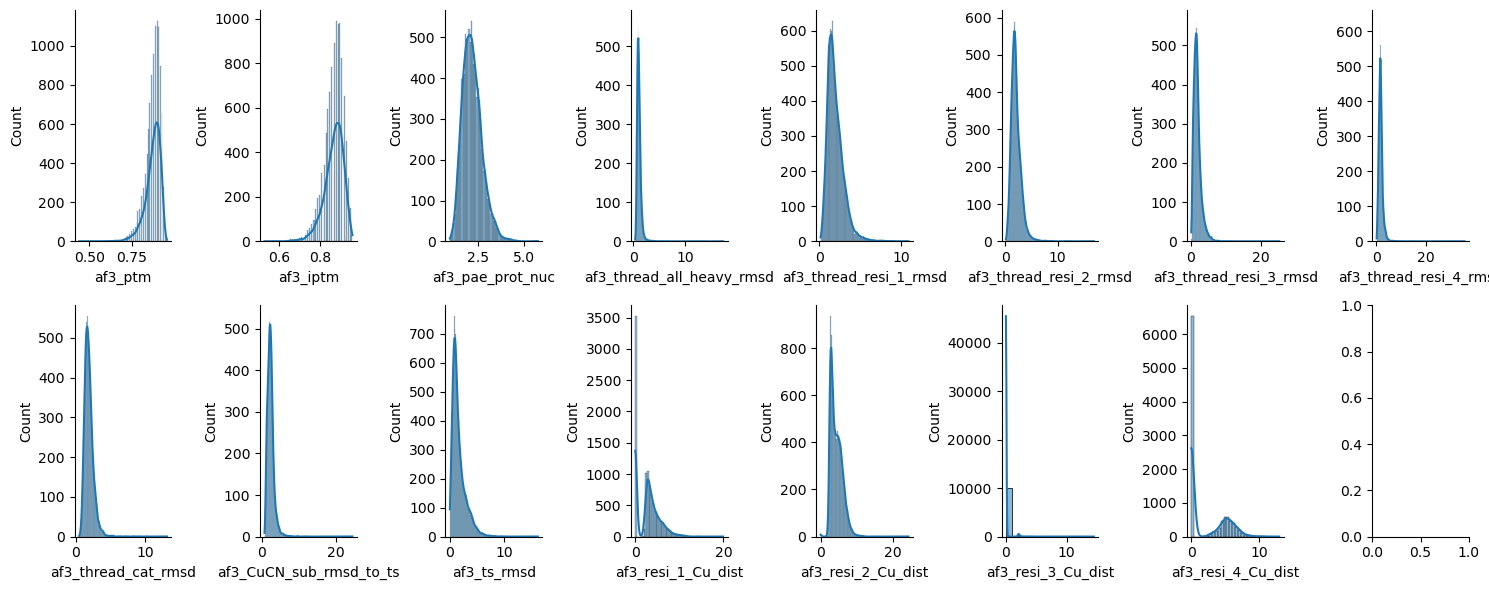

In [100]:
jupyter_utils.make_dist_plots(scores,af3_features,ncols = 8,savefig=f'scores_mpnn-fr_rd_2_filtered_af3_features.png')

In [108]:
#filter for both substrates
scores_filtered = scores.copy()

metrics_greater_than = {'af3_ptm':0.8, 'af3_iptm':0.75}
metrics_smaller_than = {'af3_thread_all_heavy_rmsd':1.25, 'af3_thread_resi_1_rmsd':1.5, 'af3_thread_resi_2_rmsd':3, 'af3_thread_resi_3_rmsd':1.5, 'af3_thread_resi_4_rmsd':1.5, \
                        'af3_resi_1_Cu_dist':2.8, 'af3_resi_3_Cu_dist':2.2, 'af3_resi_4_Cu_dist':2.8}

for metric in metrics_greater_than:
    scores_filtered = scores_filtered[scores_filtered[metric] >= metrics_greater_than[metric]]
for metric in metrics_smaller_than:
    scores_filtered = scores_filtered[scores_filtered[metric] < metrics_smaller_than[metric]]

len(scores_filtered)

145

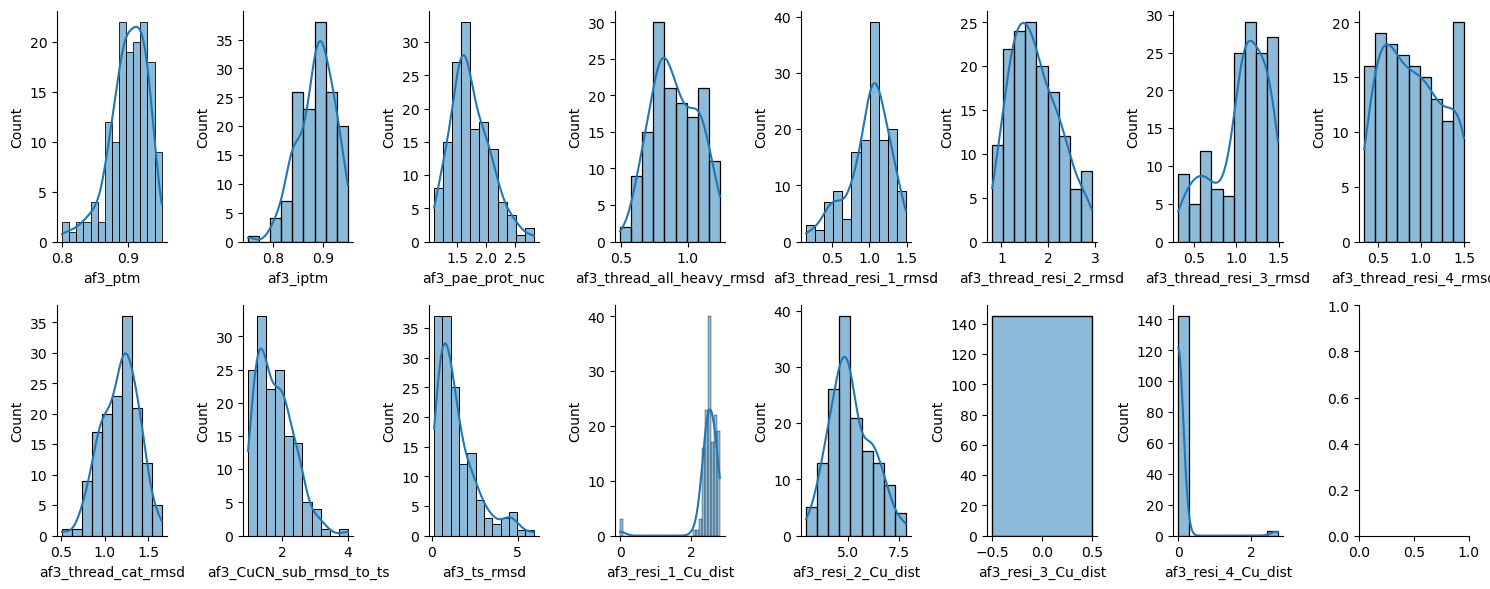

In [106]:
jupyter_utils.make_dist_plots(scores_filtered,af3_features,ncols = 8,savefig=f'scores_mpnn-fr_rd_2_filtered_af3_features.png')

In [109]:
scores_filtered.to_csv(f'scores_mpnn-fr_rd_2_filtered_af3_filtered.csv')

In [111]:
filtered_designs_dir = f'/home/wewang/projects/copper_enzymes/pipelines/diffusion_092025/filtered_designs'
shutil.rmtree(filtered_designs_dir,ignore_errors=True)
os.makedirs(filtered_designs_dir,exist_ok= True)

for i, row in scores_filtered.iterrows():
    out_path = os.path.join(filtered_designs_dir, row['name'] + '.pdb')
    pymol_utils.align_af3_to_design(row['path'],row['af3_path'],out_path)

In [112]:
scores_filtered = pd.read_csv(f'scores_mpnn-fr_rd_2_filtered_af3_filtered.csv')

selected_designs_dir = f'/home/wewang/projects/copper_enzymes/pipelines/diffusion_092025/filtered_designs'

selected_pdb_list = glob.glob(f'{selected_designs_dir}/*.pdb')
selected_pdb_list = [os.path.basename(pdb) for pdb in selected_pdb_list]

for i, row in scores_filtered.iterrows():
    if os.path.basename(row['path']) in selected_pdb_list:
        scores_filtered.at[i,'selected'] = 'Yes'
scores_selected = scores_filtered[scores_filtered['selected']=='Yes']
scores_selected.to_csv(f'scores_mpnn-fr_rd_2_filtered_af3_filtered_selected.csv')